In [2]:
from pathlib import *
import matplotlib.ticker
import matplotlib.pyplot
import pandas

import tarfile

In [3]:
# SLO is 500 microseconds
SERVICE_LEVEL_OBJECTIVE = 500

def parse_p99(tar_file : str) -> pandas.DataFrame:
    rows = []

    with tarfile.open(tar_file, "r:gz") as tar:
        for member in tar.getmembers():
            member_path = Path(member.name)
            if member_path.name != 'leader.log':
                continue

            queries_per_second = int(member_path.parent.name.split("_")[1])

            with tar.extractfile(member) as log_file:
                raw_data    = log_file.read().decode().splitlines(keepends=True)

                actual_queries_per_second = float(raw_data[-7].split()[3])

                rows.append({
                    'qps':        actual_queries_per_second,
                    'read_p99':   float(raw_data[-11].split()[-1]),
                    'update_p99': float(raw_data[-11].split()[-1]),
                    'read_p95':   float(raw_data[-11].split()[-2]),
                    'update_p95': float(raw_data[-11].split()[-2]),
                })
    
    return pandas.DataFrame(rows).sort_values('qps').set_index('qps')

def graph_p99(directory : str) -> None:
    data_frame = parse_p99(directory)

    matplotlib.pyplot.figure(figsize=(12, 6))
    #matplotlib.pyplot.plot(data_frame['read_p99'],   marker='s')
    matplotlib.pyplot.plot(data_frame['update_p99'], marker='s', linestyle='-')
    matplotlib.pyplot.axhline(y=SERVICE_LEVEL_OBJECTIVE, color='r', linestyle='--')
    matplotlib.pyplot.legend(['update_p99', 'SLO'])

    matplotlib.pyplot.xlabel("Queries Per Second")
    matplotlib.pyplot.ylabel("P99 Latency (μs)")

    matplotlib.pyplot.grid(True, axis='both', linestyle=':', alpha=0.5)

    matplotlib.pyplot.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x) // 1000}K" if x >= 1000 else str(int(x))))

    matplotlib.pyplot.xlim(left=20_000, right=400_000)
    matplotlib.pyplot.ylim(bottom=0, top=1000)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

def graph_p99_comparison(experiments : list[tuple[str, str]]) -> None:
    figure, axis = matplotlib.pyplot.subplots(figsize=(12, 6))

    axis.axhline(y=SERVICE_LEVEL_OBJECTIVE, color='r', linestyle='--')
    axis.set_xlabel("Queries Per Second")
    axis.set_ylabel("P99 Latency (μs)")
    axis.set_xlim(left=20_000, right=400_000)
    axis.set_ylim(bottom=0, top=5000)
    axis.grid(True, axis='both', linestyle=':', alpha=0.5)

    axis.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x) // 1000}K" if x >= 1000 else str(int(x))))

    legend : list[str] = ['Service Level Objective']

    for (directory, experiment_name) in experiments:
        data_frame = parse_p99(directory)

        #axis.plot(data_frame['read_p99'],   marker='s', linestyle='-.')
        axis.plot(data_frame['update_p99'], marker='s', linestyle='-')

        legend.append(experiment_name)
    
    matplotlib.pyplot.legend(legend)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

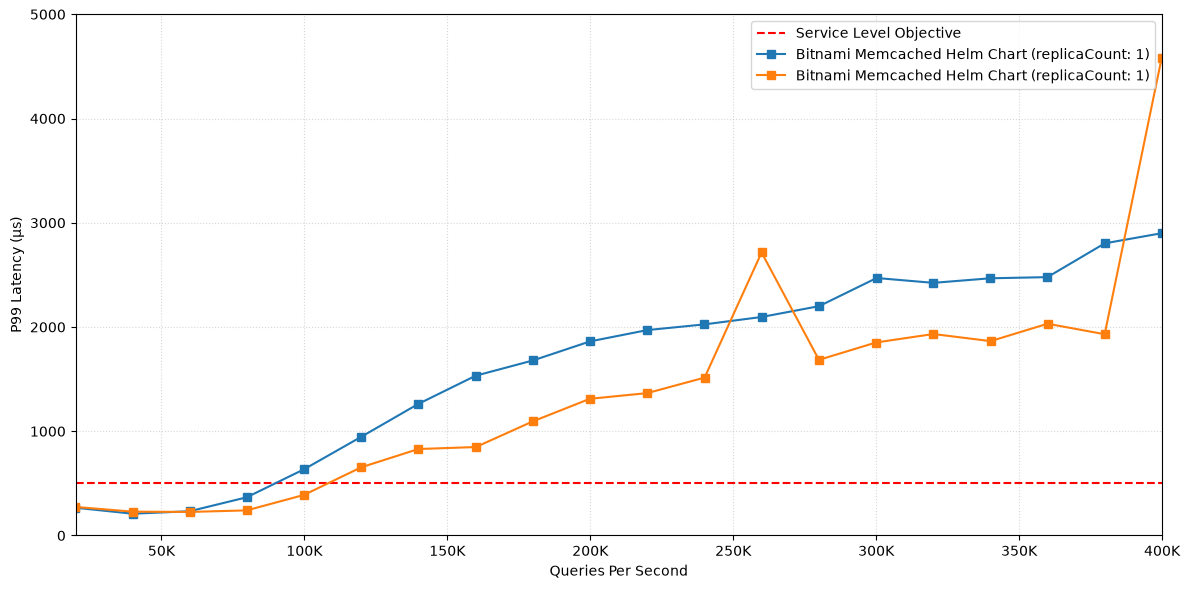

In [ ]:
graph_p99_comparison([
    ("bitnami_memcached/1replica16core1.tar.gz", "Bitnami Memcached Helm Chart (replicaCount: 1)"),
    #("all_deployed_via_kubernetes/exp1.tar.gz", "Kubernetes"),
    #("all_deployed_via_kubernetes/exp2.tar.gz", "Kubernetes"),
    #("bare_metal/exp1.tar.gz",                  "Bare-metal"),
    #("bare_metal/exp2.tar.gz",                  "Bare-metal"),
])